In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv("../data/processed/covid_indonesia_processed.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             1143 non-null   datetime64[ns]
 1   cases            1143 non-null   int64         
 2   deaths           1143 non-null   int64         
 3   recovered        1143 non-null   int64         
 4   daily_cases      1143 non-null   float64       
 5   daily_deaths     1143 non-null   float64       
 6   daily_recovered  1143 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 62.6 KB


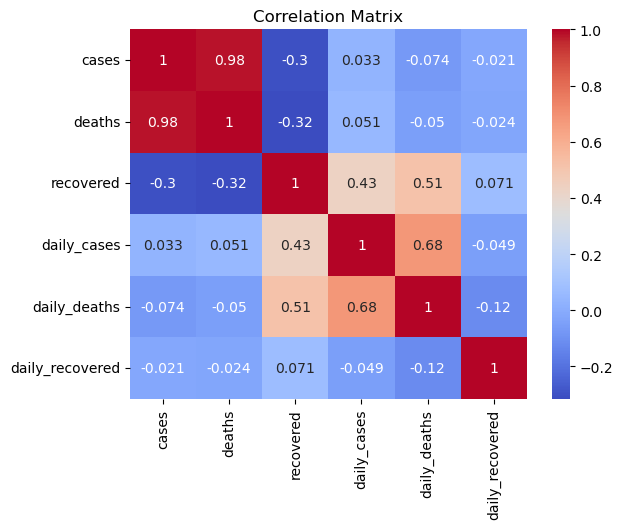

In [2]:
df.info()
df.describe()

corr = df[["cases","deaths","recovered","daily_cases","daily_deaths","daily_recovered"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

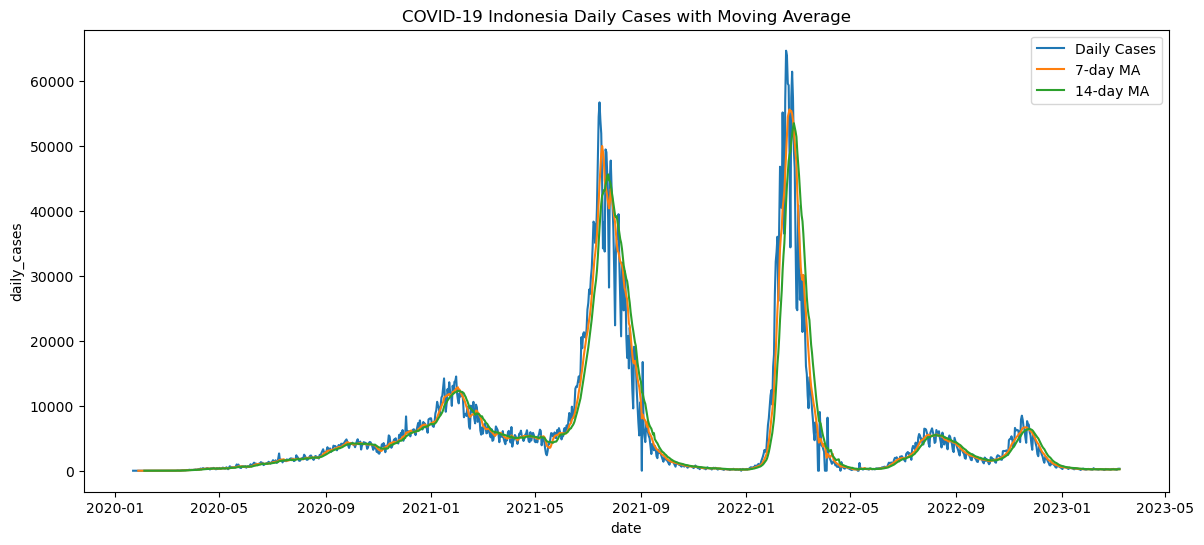

In [7]:
plt.figure(figsize=(14,6))
sns.lineplot(x="date", y="daily_cases", data=df, label="Daily Cases")
plt.plot(df["date"], df["daily_cases"].rolling(7).mean(), label="7-day MA")
plt.plot(df["date"], df["daily_cases"].rolling(14).mean(), label="14-day MA")
plt.legend()
plt.title("COVID-19 Indonesia Daily Cases with Moving Average")
plt.savefig("../reports/daily_cases_trend.png", dpi=300)
plt.show()

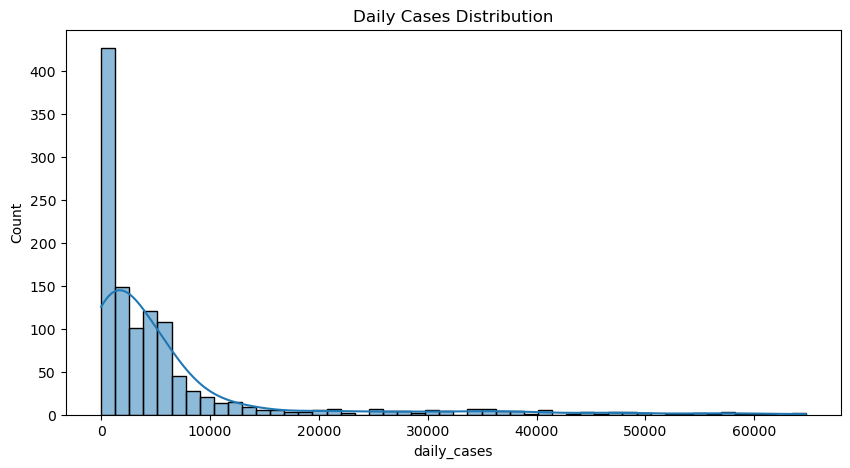

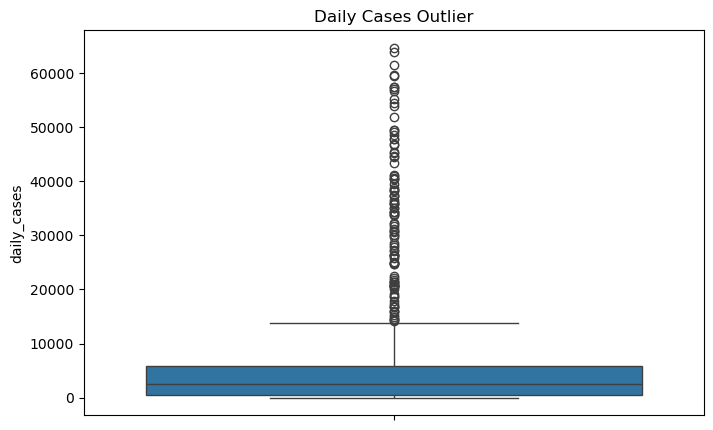

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df["daily_cases"], bins=50, kde=True)
plt.title("Daily Cases Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y=df["daily_cases"])
plt.title("Daily Cases Outlier")
plt.show()

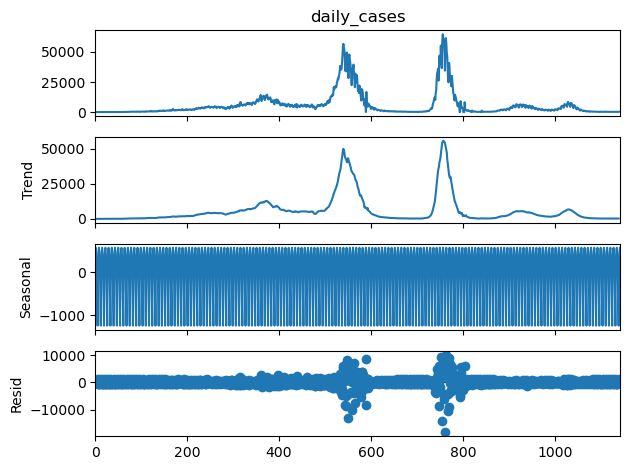

In [8]:
result = seasonal_decompose(df["daily_cases"], model="additive", period=7)
result.plot()
plt.savefig("../reports/seasonality_decomposition.png", dpi=300)
plt.show()

## 📊 Exploratory Data Analysis (EDA) Summary

**Dataset Overview**
  - 1143 daily records spanning ~3 years.
  - Columns include cumulative counts (`cases`, `deaths`, `recovered`) and derived daily metrics (`daily_cases`, `daily_deaths`, `daily_recovered`).

**Correlation Insights**
  - Strong positive correlation between cumulative cases and deaths (~0.98).
  - Negative correlation between cases and recoveries (~‑0.3), suggesting recovery reporting does not align directly with case surges.

**Trend Analysis**
  - Multiple major waves observed, with peaks around mid‑2021 and mid‑2022 reaching ~60k daily cases.
  - 7‑day and 14‑day moving averages highlight sharp rises followed by steep declines.

**Distribution & Outliers**
  - Daily case counts are highly skewed: most days show relatively low numbers, but extreme spikes occur.
  - Boxplot confirms numerous outliers, reflecting sudden surges during pandemic waves.

**Seasonality & Decomposition**
  - Clear weekly seasonality pattern (likely reporting or weekend effect).
  - Trend component emphasizes two major waves followed by a decline.
  - Residuals show high variance around peaks, indicating external shocks (e.g., new variants, policy changes).

**Key Takeaways**
  - Data is skewed with extreme outliers → robust modeling techniques are needed (e.g., log transform, outlier handling).
  - Weekly seasonality must be considered in forecasting models.
  - Strong link between cases and deaths → lagged features could improve predictive performance.
  - Major waves align with known pandemic phases, suggesting time‑series models (Prophet, ARIMA, LSTM) are more suitable than simple regression.
